<div style="background-color:#F3F2EE">
    <br /><br />
        <p style="text-align: center;">
            <font size="6" color='#0A1781'>
                <strong>
                    NLP Triagem Inteligente Financeira - Data Science Project
                </strong>
              </font>
        </p>
        <p style="text-align: center;">
            <font size="6" color='#C58A1E'>
                <strong>
                    Data Preparation | Text Cleaning + Labeling
                </strong>
            </font>
        </p>
        <p style="text-align: center;">
            <font size="5" color='#C58A1E'>
                <strong>
                    Preparar o dataset textual para modelagem, realizando limpeza controlada dos textos,<br />padronização dos rótulos, tratamento de duplicidades relevantes<br />e geração das camadas silver e gold para os próximos notebooks.
                </strong>
            </font>
        </p>
    <br />
</div>

<div style="background-color:#F3F2EE">
    <p style="text-align: right;">
      <font size="4" color='#444444'>
            Roberto SSoares - LfLngLrnng
      </font>
    </p>
    <p style="text-align: right;"><font size="2" color='#444444'>
        <a href="https://www.linkedin.com/in/roberto-dos-santos-soares/">in/roberto-dos-santos-soares</a><br /><a href="https://roberto-ssoares.github.io/meu-portfolio/">Portifólio: roberto-ssoares</a>
    </p>
    <p style="text-align: right;">
        <font size="4" color='#444444'>
            " [+] Faturamento [-] Custo [+] Qualidade de vida "
        </font>
        <br />
        <font size="2" color='#918e8e'>"Mestre Bruno Jardim"
        </font>
    </p>        
    <p style="text-align: right;">        
        <font size="2" color='#918e8e'>           
        </font>
    </p>
</div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Objetivo:</strong></font>

<font size="2" color='#66666'>

>- **Ações realizadas neste notebook**
    - Leitura da base bronze
    - Seleção e padronização das colunas principais
    - Avaliação de nulos e textos vazios
    - Tratamento de duplicidades
    - Criação de versão textual preparada para baseline
    - Preservação do texto original para uso futuro com transformer
    - Padronização de labels
    - Geração de split de validação
    - Exportação das bases silver e gold

>- **Justificativa técnica**
    - Em NLP aplicado, a preparação dos dados precisa equilibrar limpeza e preservação semântica.
    - Limpeza excessiva pode remover sinal útil; limpeza insuficiente pode aumentar ruído.
    - Esta etapa busca criar uma base consistente para o baseline com TF-IDF + Logistic Regression, preservando também uma versão adequada para modelos mais avançados.

>- **Resultados esperados**
    - Base pronta para modelagem clássica
    - Texto original preservado para transformer
    - Labels consistentes
    - Split de treino, validação e teste definido
    - Arquivos organizados em silver e gold

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📚 Instalando e Carregando os Pacotes¶</strong></font>

<font size="3" color='#66666'></font></div>

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 1. Caminhos de Diretórios</strong></font>

<font size="2" color='#66666'></font></div>

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_DIR = PROJECT_ROOT / "data"

BRONZE_DIR = DATA_DIR / "01-bronze"
SILVER_DIR = DATA_DIR / "02-silver"
GOLD_DIR = DATA_DIR / "03-gold"

DOCS_DIR = PROJECT_ROOT / "docs"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = ARTIFACTS_DIR / "reports"

SILVER_DIR.mkdir(parents=True, exist_ok=True)
GOLD_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BRONZE_DIR  :", BRONZE_DIR)
print("SILVER_DIR  :", SILVER_DIR)
print("GOLD_DIR    :", GOLD_DIR)
print("DOCS_DIR    :", DOCS_DIR)
print("REPORTS_DIR :", REPORTS_DIR)

PROJECT_ROOT: D:\_DS-Projects\nlp-triagem-inteligente-financeira
BRONZE_DIR  : D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\01-bronze
SILVER_DIR  : D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\02-silver
GOLD_DIR    : D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\03-gold
DOCS_DIR    : D:\_DS-Projects\nlp-triagem-inteligente-financeira\docs
REPORTS_DIR : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 2. Leitura da base bronze</strong></font>

<font size="2" color='#66666'>
    
>- Nesta etapa carregamos a base gerada no Notebook 02.
    - Para evitar dependência desnecessária de parquet, a leitura principal será feita a partir do CSV da camada bronze.
    
</font></div>

In [3]:
bronze_csv_path = BRONZE_DIR / "faq_bacen_bronze.csv"

df = pd.read_csv(bronze_csv_path)

print("Shape da base bronze:", df.shape)
df.head()

Shape da base bronze: (1678, 9)


,Unnamed: 0,question,category,answer,split,question_num_chars,question_num_words,answer_num_chars,answer_num_words
0,0,Quais são as condições dos Créditos para Benef...,Programa Nacional de Fortalecimento da Agricul...,Os créditos para Beneficiários do PNCF e PNRA ...,train,70,12,1244,197
1,1,Quais são os principais tipos de operações de ...,"Empréstimo, financiamento e arrendamento merca...","Empréstimo, financiamento e arrendamento merca...",train,54,9,837,124
2,2,Quais os prazos para pagamento de cheques?,SEM-CATEGORIA,Existem dois prazos que devem ser observados:p...,train,42,7,711,125
3,3,Quem pode se associar a uma cooperativa de cré...,Cooperativas de crédito Como me associar a um...,O ingresso nas cooperativas é livre a todos qu...,train,51,9,499,73
4,4,Quem é responsável pelos dados inseridos no SCR?,Sistema de Informações de Créditos (SCR) Respo...,A responsabilidade pelos dados dos clientes é ...,train,48,8,293,44


In [4]:
df.columns.tolist()

['Unnamed: 0',
 'question',
 'category',
 'answer',
 'split',
 'question_num_chars',
 'question_num_words',
 'answer_num_chars',
 'answer_num_words']

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 3. Seleção das colunas relevantes</strong></font>

<font size="2" color='#66666'>
    
>- Para o MVP, vamos trabalhar com as colunas:
    - `question`: texto principal de entrada
    - `category`: target principal
    - `answer`: conteúdo útil para futuras extensões
    - `split`: partição original do dataset
    
</font></div>

In [5]:
required_columns = ["question", "category", "answer", "split"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Colunas ausentes na base bronze: {missing_columns}")

df_prep = df[required_columns].copy()

print("Shape inicial de df_prep:", df_prep.shape)
df_prep.head()

Shape inicial de df_prep: (1678, 4)


,question,category,answer,split
0,Quais são as condições dos Créditos para Benef...,Programa Nacional de Fortalecimento da Agricul...,Os créditos para Beneficiários do PNCF e PNRA ...,train
1,Quais são os principais tipos de operações de ...,"Empréstimo, financiamento e arrendamento merca...","Empréstimo, financiamento e arrendamento merca...",train
2,Quais os prazos para pagamento de cheques?,SEM-CATEGORIA,Existem dois prazos que devem ser observados:p...,train
3,Quem pode se associar a uma cooperativa de cré...,Cooperativas de crédito Como me associar a um...,O ingresso nas cooperativas é livre a todos qu...,train
4,Quem é responsável pelos dados inseridos no SCR?,Sistema de Informações de Créditos (SCR) Respo...,A responsabilidade pelos dados dos clientes é ...,train


In [6]:
for col in ["question", "category", "answer", "split"]:
    df_prep[col] = df_prep[col].astype(str).str.strip()

df_prep.info()

<class 'pandas.DataFrame'>
RangeIndex: 1678 entries, 0 to 1677
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   question  1678 non-null   str  
 1   category  1678 non-null   str  
 2   answer    1678 non-null   str  
 3   split     1678 non-null   str  
dtypes: str(4)
memory usage: 1.1 MB


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 4. Nulos lógicos e textos vazios</strong></font>

<font size="2" color='#66666'>
    
>- Mesmo após leitura bem-sucedida, precisamos verificar registros vazios ou com conteúdo insuficiente nas colunas essenciais.
    
</font></div>

In [7]:
empty_summary = pd.DataFrame(
    {
        "coluna": ["question", "category", "answer", "split"],
        "qtd_vazios": [
            (df_prep["question"] == "").sum(),
            (df_prep["category"] == "").sum(),
            (df_prep["answer"] == "").sum(),
            (df_prep["split"] == "").sum(),
        ],
    }
)

empty_summary["pct_vazios"] = (empty_summary["qtd_vazios"] / len(df_prep) * 100).round(2)
empty_summary

,coluna,qtd_vazios,pct_vazios
0,question,0,0.0
1,category,0,0.0
2,answer,0,0.0
3,split,0,0.0


In [8]:
before_drop_shape = df_prep.shape

df_prep = df_prep[
    (df_prep["question"] != "") &
    (df_prep["category"] != "") &
    (df_prep["split"] != "")
].copy()

after_drop_shape = df_prep.shape

print("Shape antes da remoção:", before_drop_shape)
print("Shape depois da remoção:", after_drop_shape)
print("Registros removidos:", before_drop_shape[0] - after_drop_shape[0])

Shape antes da remoção: (1678, 4)
Shape depois da remoção: (1678, 4)
Registros removidos: 0


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 5. Duplicidades</strong></font>

<font size="2" color='#66666'>
    
>- Nesta etapa medimos duplicidades relevantes e removemos duplicatas exatas completas.

>- Decisão do MVP:
    - remover duplicidade exata em `question + category + answer + split`
    - manter casos semanticamente parecidos para análise futura
    
</font></div>


In [9]:
dup_summary_before = pd.DataFrame(
    {
        "criterio": [
            "question",
            "question + category",
            "question + category + answer",
            "question + category + answer + split",
        ],
        "qtd_duplicados": [
            df_prep.duplicated(subset=["question"]).sum(),
            df_prep.duplicated(subset=["question", "category"]).sum(),
            df_prep.duplicated(subset=["question", "category", "answer"]).sum(),
            df_prep.duplicated(subset=["question", "category", "answer", "split"]).sum(),
        ],
    }
)

dup_summary_before

,criterio,qtd_duplicados
0,question,0
1,question + category,0
2,question + category + answer,0
3,question + category + answer + split,0


In [10]:
rows_before_dedup = len(df_prep)

df_prep = df_prep.drop_duplicates(
    subset=["question", "category", "answer", "split"]
).copy()

rows_after_dedup = len(df_prep)

print("Linhas antes do drop_duplicates:", rows_before_dedup)
print("Linhas depois do drop_duplicates:", rows_after_dedup)
print("Duplicatas exatas removidas:", rows_before_dedup - rows_after_dedup)

Linhas antes do drop_duplicates: 1678
Linhas depois do drop_duplicates: 1678
Duplicatas exatas removidas: 0


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 6. Limpeza textual controlada</strong></font>

<font size="2" color='#66666'>
    
>- A estratégia de limpeza será conservadora.

>- **O que faremos**
    - *lowercase*
    - *remoção de espaços excedentes*
    - *normalização Unicode*
    - *remoção de acentos para a versão de baseline*
    - *remoção controlada de pontuação*

>- **O que não faremos agora**
    - stemming
    - lemmatization
    - remoção agressiva de stopwords
    - remoção de números de forma indiscriminada

>- Essa decisão preserva melhor o sinal do domínio financeiro.
    
</font></div>


In [11]:
def strip_accents(text: str) -> str:
    text = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in text if not unicodedata.combining(ch))


def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def remove_punctuation_keep_alnum(text: str) -> str:
    return re.sub(r"[^\w\s]", " ", text)


def clean_text_for_baseline(text: str) -> str:
    text = str(text)
    text = text.strip().lower()
    text = strip_accents(text)
    text = remove_punctuation_keep_alnum(text)
    text = normalize_whitespace(text)
    return text


def clean_text_light(text: str) -> str:
    text = str(text)
    text = text.strip().lower()
    text = normalize_whitespace(text)
    return text

In [12]:
df_prep["question_raw"] = df_prep["question"].astype(str)
df_prep["question_clean_light"] = df_prep["question_raw"].apply(clean_text_light)
df_prep["question_clean"] = df_prep["question_raw"].apply(clean_text_for_baseline)

df_prep["question_raw_num_words"] = df_prep["question_raw"].str.split().str.len()
df_prep["question_clean_num_words"] = df_prep["question_clean"].str.split().str.len()

df_prep[["question_raw", "question_clean_light", "question_clean"]].head(10)

,question_raw,question_clean_light,question_clean
0,Quais são as condições dos Créditos para Benef...,quais são as condições dos créditos para benef...,quais sao as condicoes dos creditos para benef...
1,Quais são os principais tipos de operações de ...,quais são os principais tipos de operações de ...,quais sao os principais tipos de operacoes de ...
2,Quais os prazos para pagamento de cheques?,quais os prazos para pagamento de cheques?,quais os prazos para pagamento de cheques
3,Quem pode se associar a uma cooperativa de cré...,quem pode se associar a uma cooperativa de cré...,quem pode se associar a uma cooperativa de cre...
4,Quem é responsável pelos dados inseridos no SCR?,quem é responsável pelos dados inseridos no scr?,quem e responsavel pelos dados inseridos no scr
5,"Autoridades públicas como juízes, promotores e...","autoridades públicas como juízes, promotores e...",autoridades publicas como juizes promotores e ...
6,Quais os principais tipos de aplicação finance...,quais os principais tipos de aplicação finance...,quais os principais tipos de aplicacao finance...
7,Como iniciar a declaração?,como iniciar a declaração?,como iniciar a declaracao
8,Qual o fundamento do processo administrativo s...,qual o fundamento do processo administrativo s...,qual o fundamento do processo administrativo s...
9,Sou imigrante e solicitei refúgio no Brasil. P...,sou imigrante e solicitei refúgio no brasil. p...,sou imigrante e solicitei refugio no brasil po...


In [13]:
sample_compare = df_prep[["question_raw", "question_clean"]].sample(10, random_state=42)
sample_compare

,question_raw,question_clean
1601,Além de decretar e acompanhar o regime de reso...,alem de decretar e acompanhar o regime de reso...
482,Moro no Brasil e possuo aqui uma conta em reai...,moro no brasil e possuo aqui uma conta em reai...
203,Fiz uma compra em moeda estrangeira pelo cartã...,fiz uma compra em moeda estrangeira pelo carta...
49,"Se eu não tiver acesso à internet, é possível ...",se eu nao tiver acesso a internet e possivel f...
1290,Como faço para consultar meus dados em determi...,como faco para consultar meus dados em determi...
481,O que ocorre se meu cadastro for cancelado?,o que ocorre se meu cadastro for cancelado
1666,Posso registrar ou fazer alguma alteração na m...,posso registrar ou fazer alguma alteracao na m...
611,Todos os relacionamentos do CCS fazem parte do...,todos os relacionamentos do ccs fazem parte do...
1623,Deve ser realizado contrato de câmbio para as ...,deve ser realizado contrato de cambio para as ...
518,Como pago a multa por entrega em atraso da dec...,como pago a multa por entrega em atraso da dec...


In [14]:
df_prep[["question_raw_num_words", "question_clean_num_words"]].describe()

,question_raw_num_words,question_clean_num_words
count,1678.000000,1678.000000
mean,11.555423,11.614422
std,5.299067,5.344736
min,1.000000,1.000000
25%,8.000000,8.000000
50%,11.000000,11.000000
75%,14.000000,14.000000
max,42.000000,42.000000


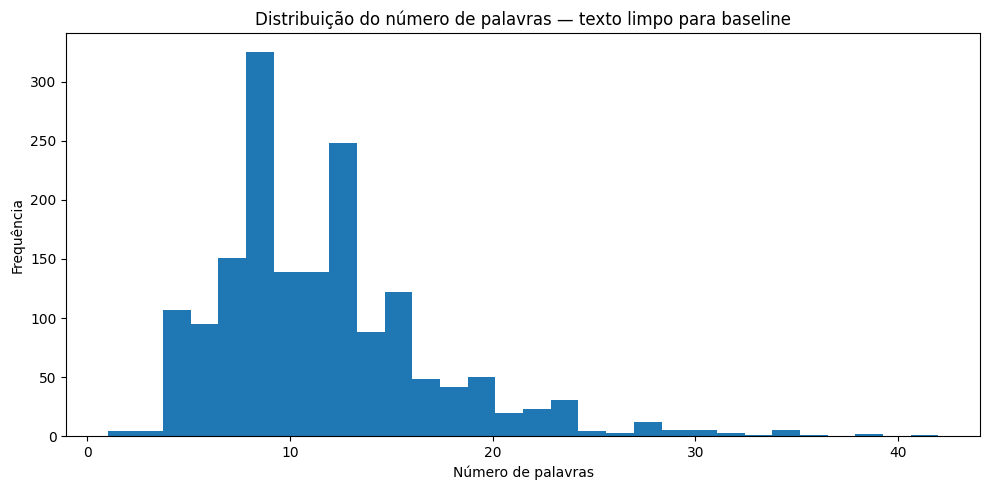

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(df_prep["question_clean_num_words"], bins=30)
plt.title("Distribuição do número de palavras — texto limpo para baseline")
plt.xlabel("Número de palavras")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 7. Padronização dos labels</strong></font>

<font size="2" color='#66666'>
    
>- Nesta etapa vamos padronizar os rótulos textuais para evitar inconsistências de capitalização e espaços.
    
</font></div>


In [16]:
def normalize_label(label: str) -> str:
    label = str(label).strip()
    label = normalize_whitespace(label)
    return label

df_prep["category_original"] = df_prep["category"].astype(str)
df_prep["category_final"] = df_prep["category_original"].apply(normalize_label)

print("Categorias originais:", df_prep["category_original"].nunique())
print("Categorias finais   :", df_prep["category_final"].nunique())

Categorias originais: 242
Categorias finais   : 242


In [17]:
category_counts = (
    df_prep["category_final"]
    .value_counts()
    .rename_axis("category_final")
    .reset_index(name="count")
)

category_counts.head(20)

,category_final,count
0,SEM-CATEGORIA,270
1,Crédito Imobiliário,25
2,Registrato,25
3,Sistema de Pagamentos em Moeda Local (SML),24
4,Cartão de Crédito e Crédito Rotativo,24
5,Tarifas bancárias,22
6,Conta-Salário e Portabilidade Salarial,22
7,Programa Nacional de Fortalecimento da Agricul...,20
8,CBE - Capitais Brasileiros no Exterior Informa...,20
9,Censo Anual de Capitais Estrangeiros no País,17


In [18]:
RARE_CLASS_THRESHOLD = 5

rare_classes = category_counts[category_counts["count"] < RARE_CLASS_THRESHOLD].copy()

print("Quantidade de classes raras (threshold < 5):", rare_classes.shape[0])
rare_classes

Quantidade de classes raras (threshold < 5): 126


,category_final,count
116,Cheques Endosso,4
117,Moedas Virtuais,4
118,Cadastro de Clientes do Sistema Financeiro Nac...,4
119,Segunda Família do Real,4
120,Processo Administrativo Sancionador Decisão,4
...,...,...
237,Calculadora do cidadão Financiamento com Prest...,1
238,Cédulas e moedas para troco,1
239,Crédito Rural Títulos de Crédito Rural,1
240,Crédito Rural Proagro,1


<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Decisão de preparação sobre classes raras</strong></font>

<font size="2" color='#66666'>
    
>- Para o MVP, **não vamos agrupar classes automaticamente nesta etapa**.

>- **Motivo**
    - queremos preservar a taxonomia original
    - o baseline ajudará a mostrar onde há maior confusão
    - agrupamentos podem ser feitos depois com base em evidência analítica

>- Assim, a coluna-alvo do projeto seguirá como:
    **`category_final`**
    
</font></div>


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 8. Estratégia de split para modelagem</strong></font>

<font size="2" color='#66666'>
    
>- Usaremos:
    - `train` oficial do dataset como base de treino
    - `test` oficial do dataset como teste final
    - split adicional de validação sobre o treino oficial

>- Isso preserva a separação original e cria uma base adequada para seleção de modelo.
    
</font></div>


In [19]:
train_base = df_prep[df_prep["split"] == "train"].copy()
test_gold = df_prep[df_prep["split"] == "test"].copy()

train_class_counts = train_base["category_final"].value_counts()
can_stratify = train_class_counts.min() >= 2

print("Shape train_base:", train_base.shape)
print("Shape test_gold :", test_gold.shape)
print("Estratificação viável?", can_stratify)

Shape train_base: (1305, 11)
Shape test_gold : (373, 11)
Estratificação viável? False


In [20]:
split_kwargs = {
    "test_size": 0.20,
    "random_state": 42,
    "shuffle": True,
}

if can_stratify:
    split_kwargs["stratify"] = train_base["category_final"]
else:
    split_kwargs["stratify"] = None

train_gold, valid_gold = train_test_split(train_base, **split_kwargs)

train_gold = train_gold.copy()
valid_gold = valid_gold.copy()
test_gold = test_gold.copy()

train_gold["model_split"] = "train"
valid_gold["model_split"] = "valid"
test_gold["model_split"] = "test"

print("train_gold:", train_gold.shape)
print("valid_gold:", valid_gold.shape)
print("test_gold :", test_gold.shape)

train_gold: (1044, 12)
valid_gold: (261, 12)
test_gold : (373, 12)


In [21]:
split_distribution = pd.concat(
    [
        train_gold["category_final"].value_counts(normalize=True).rename("train_pct"),
        valid_gold["category_final"].value_counts(normalize=True).rename("valid_pct"),
        test_gold["category_final"].value_counts(normalize=True).rename("test_pct"),
    ],
    axis=1
).fillna(0).round(4)

split_distribution.head(20)

,train_pct,valid_pct,test_pct
category_final,,,
SEM-CATEGORIA,0.1628,0.1303,0.1769
Crédito Imobiliário,0.0192,0.0038,0.0107
Registrato,0.0153,0.0115,0.0161
Sistema de Pagamentos em Moeda Local (SML),0.0144,0.0077,0.0188
Programa Nacional de Fortalecimento da Agricultura Familiar - Pronaf,0.0134,0.0000,0.0161
CBE - Capitais Brasileiros no Exterior Informando os ativos no exterior,0.0134,0.0153,0.0054
Tarifas bancárias,0.0134,0.0115,0.0134
Cartão de Crédito e Crédito Rotativo,0.0125,0.0192,0.0161
Conta-Salário e Portabilidade Salarial,0.0115,0.0230,0.0107


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 9. Label mapping</strong></font>

<font size="2" color='#66666'>
    
>- Vamos gerar uma codificação numérica simples para uso posterior nos modelos.
    
</font></div>


In [22]:
label_list = sorted(df_prep["category_final"].unique())
label_to_id = {label: idx for idx, label in enumerate(label_list)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

label_mapping_df = pd.DataFrame(
    {
        "label_id": list(id_to_label.keys()),
        "category_final": list(id_to_label.values()),
    }
)

label_mapping_df.head(20)

,label_id,category_final
0,0,Acordo Administrativo em Processo de Supervisã...
1,1,Alerta contra golpes envolvendo o nome do Banc...
2,2,Aplicações financeiras
3,3,Arranjos de Pagamentos Compras e relações de c...
4,4,Arranjos de Pagamentos Conceitos importantes
5,5,Arranjos de Pagamentos Informações Gerais
6,6,"Arranjos de Pagamentos Interoperabilidade, liq..."
7,7,Arranjos de Pagamentos Supervisão dos arranjos...
8,8,"Atendimento bancário (fila, feriados e outros)"
9,9,Bacen Jud e SISBAJUD Informações gerais


In [23]:
for part_df in [train_gold, valid_gold, test_gold]:
    part_df["label_id"] = part_df["category_final"].map(label_to_id)

silver_df = df_prep.copy()
silver_df["label_id"] = silver_df["category_final"].map(label_to_id)

selected_columns = [
    "question_raw",
    "question_clean_light",
    "question_clean",
    "category_original",
    "category_final",
    "label_id",
    "answer",
    "split",
]

silver_df = silver_df[selected_columns].copy()

gold_columns = [
    "question_raw",
    "question_clean_light",
    "question_clean",
    "category_final",
    "label_id",
    "answer",
    "split",
    "model_split",
]

train_gold = train_gold[gold_columns].copy()
valid_gold = valid_gold[gold_columns].copy()
test_gold = test_gold[gold_columns].copy()

print("silver_df:", silver_df.shape)
print("train_gold:", train_gold.shape)
print("valid_gold:", valid_gold.shape)
print("test_gold :", test_gold.shape)

silver_df: (1678, 8)
train_gold: (1044, 8)
valid_gold: (261, 8)
test_gold : (373, 8)


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 10. Exportação das camadas silver e gold</strong></font>

<font size="2" color='#66666'>
    
>- Arquivos a serem gerados:

>- **Silver**
    - base preparada completa

>- **Gold**
    - treino
    - validação
    - teste
    - mapping de labels
    
</font></div>


In [24]:
silver_csv_path = SILVER_DIR / "faq_bacen_silver.csv"

gold_train_csv_path = GOLD_DIR / "faq_bacen_gold_train.csv"
gold_valid_csv_path = GOLD_DIR / "faq_bacen_gold_valid.csv"
gold_test_csv_path = GOLD_DIR / "faq_bacen_gold_test.csv"

label_mapping_csv_path = GOLD_DIR / "label_mapping.csv"
label_mapping_json_path = GOLD_DIR / "label_mapping.json"

silver_df.to_csv(silver_csv_path, index=False)
train_gold.to_csv(gold_train_csv_path, index=False)
valid_gold.to_csv(gold_valid_csv_path, index=False)
test_gold.to_csv(gold_test_csv_path, index=False)
label_mapping_df.to_csv(label_mapping_csv_path, index=False)

with open(label_mapping_json_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "label_to_id": label_to_id,
            "id_to_label": {str(k): v for k, v in id_to_label.items()},
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print("Arquivos exportados com sucesso.")
print(silver_csv_path)
print(gold_train_csv_path)
print(gold_valid_csv_path)
print(gold_test_csv_path)
print(label_mapping_csv_path)
print(label_mapping_json_path)

Arquivos exportados com sucesso.
D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\02-silver\faq_bacen_silver.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\03-gold\faq_bacen_gold_train.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\03-gold\faq_bacen_gold_valid.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\03-gold\faq_bacen_gold_test.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\03-gold\label_mapping.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\03-gold\label_mapping.json


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 11. Log de decisões da preparação</strong></font>

<font size="2" color='#66666'>
    
>- Registrar decisões técnicas e de negócio nesta etapa ajuda a fortalecer reprodutibilidade e interpretação do pipeline.
    
</font></div>


In [25]:
preparation_log = pd.DataFrame(
    [
        [
            "Seleção de colunas principais",
            "Uso de question, category, answer e split como núcleo do MVP",
            "Redução de escopo e foco na tarefa principal de classificação",
            "Pipeline mais simples e rastreável",
        ],
        [
            "Remoção de duplicatas exatas",
            "Drop em question + category + answer + split",
            "Evitar repetição artificial sem perder diversidade semântica",
            "Base mais limpa para treino e avaliação",
        ],
        [
            "Limpeza textual conservadora",
            "Lowercase, remoção de acentos, pontuação controlada e espaços excedentes",
            "Melhorar baseline sem destruir sinal do domínio",
            "Texto limpo para TF-IDF e texto bruto preservado",
        ],
        [
            "Preservação do texto original",
            "Manutenção de question_raw para modelos avançados",
            "Transformers se beneficiam de texto menos agressivamente limpo",
            "Reuso futuro no Notebook 05",
        ],
        [
            "Sem agrupamento automático de classes raras",
            "Manutenção da taxonomia original nesta fase",
            "Evitar simplificação prematura sem evidência analítica",
            "Maior fidelidade ao problema original",
        ],
        [
            "Split de validação sobre treino oficial",
            "Train oficial dividido em train e valid",
            "Preservação do test oficial como holdout final",
            "Comparação mais confiável entre modelos",
        ],
    ],
    columns=[
        "decisao",
        "racional_tecnico",
        "racional_de_negocio",
        "impacto_esperado",
    ],
)

preparation_log

,decisao,racional_tecnico,racional_de_negocio,impacto_esperado
0,Seleção de colunas principais,"Uso de question, category, answer e split como...",Redução de escopo e foco na tarefa principal d...,Pipeline mais simples e rastreável
1,Remoção de duplicatas exatas,Drop em question + category + answer + split,Evitar repetição artificial sem perder diversi...,Base mais limpa para treino e avaliação
2,Limpeza textual conservadora,"Lowercase, remoção de acentos, pontuação contr...",Melhorar baseline sem destruir sinal do domínio,Texto limpo para TF-IDF e texto bruto preservado
3,Preservação do texto original,Manutenção de question_raw para modelos avançados,Transformers se beneficiam de texto menos agre...,Reuso futuro no Notebook 05
4,Sem agrupamento automático de classes raras,Manutenção da taxonomia original nesta fase,Evitar simplificação prematura sem evidência a...,Maior fidelidade ao problema original
5,Split de validação sobre treino oficial,Train oficial dividido em train e valid,Preservação do test oficial como holdout final,Comparação mais confiável entre modelos


In [26]:
prep_log_path = DOCS_DIR / "preparation_decision_log.csv"
preparation_log.to_csv(prep_log_path, index=False)

print("Log salvo em:", prep_log_path)

Log salvo em: D:\_DS-Projects\nlp-triagem-inteligente-financeira\docs\preparation_decision_log.csv


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 12. Encerramento do notebook</strong></font>

<font size="2" color='#66666'>
    
>- **Principais saídas desta etapa**
    - base bronze validada
    - textos preparados para baseline
    - texto original preservado para transformer
    - labels padronizados
    - split train / valid / test definido
    - camadas silver e gold exportadas
    - label mapping persistido
    - log de decisões de preparação registrado

>- **Próximo passo**
    - No **Notebook 04 — Modeling Baseline**, vamos treinar:
        - **TF-IDF + Logistic Regression**
        - sobre a base gold preparada nesta etapa.
    
</font></div>


<div style="background-color:#f3f2ee">
    
<font size="6" color='#CC403E'><strong>Fim</strong></font>

<font size="3" color='#66666'></font></div>


In [27]:
#!uv pip install nbconvert -U -q
!jupyter nbconvert --to html --template-file my-template-html-v10.tpl 03_data_preparation__text_cleaning_labeling.ipynb

[NbConvertApp] Converting notebook 03_data_preparation__text_cleaning_labeling.ipynb to html
[NbConvertApp] Writing 89323 bytes to 03_data_preparation__text_cleaning_labeling.html
